# Import Libraries

In [1]:

import os
import cv2
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import entropy

from skimage.feature import (
    hog,
    graycomatrix,
    graycoprops
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (
    RandomForestClassifier
)

from sklearn.svm import SVC

from sklearn.linear_model import (
    LogisticRegression
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

print("Libraries imported successfully.")

Libraries imported successfully.


# Circular Mean for Hue

In [2]:
def circular_mean_std(h):
    h = h.astype(np.float32)

    angles = h * 2 * np.pi / 180

    sin_mean = np.mean(np.sin(angles))
    cos_mean = np.mean(np.cos(angles))

    mean = np.arctan2(
        sin_mean,
        cos_mean
    ) * 180 / np.pi

    std = np.sqrt(
        -2 * np.log(
            np.sqrt(sin_mean**2 + cos_mean**2)
        )
    )

    return mean, std

# Feature Extraction

In [3]:
# ============================================================
# 3. FEATURE EXTRACTION
# ============================================================

def extract_features(image_path):

    # --------------------------------------------------------
    # Load and resize image
    # --------------------------------------------------------

    image = cv2.imread(image_path)

    if image is None:
        raise ValueError(f"Unable to read image: {image_path}")

    image = cv2.resize(image, (128, 128))

    # --------------------------------------------------------
    # RGB FEATURES
    # --------------------------------------------------------

    R, G, B = cv2.split(image)

    R_mean = np.mean(R)
    G_mean = np.mean(G)
    B_mean = np.mean(B)

    R_std = np.std(R)
    G_std = np.std(G)
    B_std = np.std(B)

    # --------------------------------------------------------
    # HSV FEATURES
    # --------------------------------------------------------

    hsv = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2HSV
    )

    H, S, V = cv2.split(hsv)

    H_mean, H_std = circular_mean_std(H)

    S_mean = np.mean(S)
    V_mean = np.mean(V)

    S_std = np.std(S)
    V_std = np.std(V)

    # --------------------------------------------------------
    # LAB FEATURES
    # --------------------------------------------------------

    lab = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2LAB
    )

    L, a, b = cv2.split(lab)

    L_mean = np.mean(L)
    L_std = np.std(L)

    a_mean = np.mean(a)
    a_std = np.std(a)

    b_mean = np.mean(b)
    b_std = np.std(b)

    # --------------------------------------------------------
    # GRAYSCALE
    # --------------------------------------------------------

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # --------------------------------------------------------
    # TEXTURE FEATURES
    # --------------------------------------------------------

    # Laplacian variance
    laplacian_variance = cv2.Laplacian(
        gray,
        cv2.CV_64F
    ).var()

    # GLCM
    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    glcm_contrast = graycoprops(
        glcm,
        'contrast'
    )[0, 0]

    glcm_energy = graycoprops(
        glcm,
        'energy'
    )[0, 0]

    glcm_homogeneity = graycoprops(
        glcm,
        'homogeneity'
    )[0, 0]

    # Entropy
    hist = cv2.calcHist(
        [gray],
        [0],
        None,
        [256],
        [0, 256]
    )

    hist = hist / (hist.sum() + 1e-10)

    grayscale_entropy = entropy(
        hist.flatten()
    )

    # --------------------------------------------------------
    # SHAPE FEATURES
    # --------------------------------------------------------

    _, thresh = cv2.threshold(
        gray,
        40,
        255,
        cv2.THRESH_BINARY
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) > 0:

        cnt = max(
            contours,
            key=cv2.contourArea
        )

        contour_area = cv2.contourArea(cnt)

        perimeter = cv2.arcLength(
            cnt,
            True
        )

        circularity = (
            4 * np.pi * contour_area
        ) / (
            perimeter ** 2 + 1e-5
        )

        hull = cv2.convexHull(cnt)

        hull_area = cv2.contourArea(hull)

        solidity = (
            contour_area /
            (hull_area + 1e-5)
        )

        x, y, w, h = cv2.boundingRect(cnt)

        aspect_ratio = w / (h + 1e-5)

        extent = (
            contour_area /
            (w * h + 1e-5)
        )

    else:

        contour_area = 0
        perimeter = 0
        circularity = 0
        solidity = 0
        aspect_ratio = 0
        extent = 0

    # --------------------------------------------------------
    # DARK PIXEL RATIO
    # --------------------------------------------------------

    dark_pixel_ratio = (
        np.sum(gray < 40) /
        gray.size
    )

    # --------------------------------------------------------
    # HOG FEATURES
    # --------------------------------------------------------

    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    # --------------------------------------------------------
    # FINAL FEATURE VECTOR
    # --------------------------------------------------------

    features = np.hstack([

        # RGB
        R_mean,
        G_mean,
        B_mean,
        R_std,
        G_std,
        B_std,

        # HSV
        H_mean,
        S_mean,
        V_mean,
        H_std,
        S_std,
        V_std,

        # LAB
        L_mean,
        L_std,
        a_mean,
        a_std,
        b_mean,
        b_std,

        # Texture
        laplacian_variance,
        glcm_contrast,
        glcm_energy,
        glcm_homogeneity,
        grayscale_entropy,

        # Shape
        contour_area,
        perimeter,
        circularity,
        solidity,
        aspect_ratio,
        extent,

        # Decay
        dark_pixel_ratio,

        # HOG
        hog_features
    ])

    return features


# Dataset Loading

In [6]:
# ============================================================
# 05. DATASET LOADING
# ============================================================

DATA_DIR = r"C:\Users\KIIT0001\OneDrive\Desktop\Mini_Project\Fruit-Freshness-Detection\data"

VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

class_labels = sorted([
    folder
    for folder in os.listdir(DATA_DIR)
    if os.path.isdir(
        os.path.join(
            DATA_DIR,
            folder
        )
    )
])

print("Classes:")

for i, label in enumerate(class_labels):
    print(i, "->", label)

print()
print("Total classes:", len(class_labels))

Classes:
0 -> fresh apple
1 -> fresh banana
2 -> fresh orange
3 -> rottenapples
4 -> rottenbanana
5 -> rottenoranges

Total classes: 6


# Load Images and Features

In [ ]:

X = []
y = []

start_time = time.time()

for label in class_labels:

    class_dir = os.path.join(
        DATA_DIR,
        label
    )

    image_files = [
        file
        for file in os.listdir(class_dir)
        if file.lower().endswith(
            VALID_EXTENSIONS
        )
    ]

    print(
        f"{label}: {len(image_files)} images"
    )

    for image_file in image_files:

        image_path = os.path.join(
            class_dir,
            image_file
        )

        try:

            features = extract_features(
                image_path
            )

            X.append(features)
            y.append(label)

        except Exception as e:

            print(
                "Error:",
                image_path
            )

            print(e)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(y)

elapsed = time.time() - start_time

print()
print("Feature extraction completed.")

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

print(
    f"Time: {elapsed / 60:.2f} minutes"
)

fresh apple: 1599 images
fresh banana: 1544 images
fresh orange: 1564 images
rottenapples: 1482 images
rottenbanana: 1529 images
rottenoranges: 1481 images

Feature extraction completed.
X shape: (9199, 8130)
y shape: (9199,)
Time: 1.68 minutes


# Label encoding

In [8]:
# ============================================================
# 06. LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(
    y
)

print("Label Mapping:")

for i, label in enumerate(
    label_encoder.classes_
):

    print(
        i,
        "->",
        label
    )

Label Mapping:
0 -> fresh apple
1 -> fresh banana
2 -> fresh orange
3 -> rottenapples
4 -> rottenbanana
5 -> rottenoranges


# Train-Test Split

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_encoded,

    test_size=0.20,

    random_state=42,

    stratify=y_encoded
)

print(
    "Training samples:",
    X_train.shape[0]
)

print(
    "Testing samples:",
    X_test.shape[0]
)

print(
    "Number of features:",
    X_train.shape[1]
)

Training samples: 7359
Testing samples: 1840
Number of features: 8130


# Scaling

In [10]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print(
    "Feature scaling completed."
)

Feature scaling completed.


# Define Machine Learning Models

In [11]:


models = {

    "KNN": KNeighborsClassifier(
         n_neighbors=5,
    weights="distance",
    n_jobs=-1
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    random_state=42
    ),

    "Logistic Regression": LogisticRegression(
       C=1.0,
    max_iter=2000,
    random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=42
    )
}

print("Models created:")
for name in models:
    print("-", name)

Models created:
- KNN
- Random Forest
- SVM
- Logistic Regression
- XGBoost


# Train and Compare All Models

In [12]:
# ============================================================
# 10. KNN TRAINING
# ============================================================

print("=" * 60)
print("Training: KNN")
print("=" * 60)

start_time = time.time()

knn_model = models["KNN"]

knn_model.fit(
    X_train_scaled,
    y_train
)

knn_train_time = time.time() - start_time

knn_pred = knn_model.predict(
    X_test_scaled
)

knn_accuracy = accuracy_score(
    y_test,
    knn_pred
)

knn_precision = precision_score(
    y_test,
    knn_pred,
    average="weighted",
    zero_division=0
)

knn_recall = recall_score(
    y_test,
    knn_pred,
    average="weighted",
    zero_division=0
)

knn_f1 = f1_score(
    y_test,
    knn_pred,
    average="weighted",
    zero_division=0
)

print(f"KNN Accuracy : {knn_accuracy * 100:.2f}%")
print(f"KNN Precision: {knn_precision * 100:.2f}%")
print(f"KNN Recall   : {knn_recall * 100:.2f}%")
print(f"KNN F1 Score : {knn_f1 * 100:.2f}%")
print(f"Training Time: {knn_train_time:.2f} seconds")

Training: KNN
KNN Accuracy : 64.62%
KNN Precision: 69.46%
KNN Recall   : 64.62%
KNN F1 Score : 65.47%
Training Time: 0.06 seconds


In [14]:
# ============================================================
# 11. RANDOM FOREST TRAINING
# ============================================================

print("=" * 60)
print("Training: Random Forest")
print("=" * 60)

start_time = time.time()

rf_model = models["Random Forest"]

rf_model.fit(
    X_train,
    y_train
)

rf_train_time = time.time() - start_time

rf_pred = rf_model.predict(
    X_test
)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="weighted",
    zero_division=0
)

print(
    f"Random Forest Accuracy : "
    f"{rf_accuracy * 100:.2f}%"
)

print(
    f"Random Forest Precision: "
    f"{rf_precision * 100:.2f}%"
)

print(
    f"Random Forest Recall   : "
    f"{rf_recall * 100:.2f}%"
)

print(
    f"Random Forest F1 Score : "
    f"{rf_f1 * 100:.2f}%"
)

print(
    f"Training Time: "
    f"{rf_train_time:.2f} seconds"
)

Training: Random Forest
Random Forest Accuracy : 84.62%
Random Forest Precision: 84.49%
Random Forest Recall   : 84.62%
Random Forest F1 Score : 84.52%
Training Time: 37.72 seconds


In [16]:
# ============================================================
# 12. SVM TRAINING
# ============================================================

print("=" * 60)
print("Training: SVM")
print("=" * 60)

start_time = time.time()

svm_model = models["SVM"]

svm_model.fit(
    X_train_scaled,
    y_train
)

svm_train_time = time.time() - start_time

svm_pred = svm_model.predict(
    X_test_scaled
)

svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

svm_precision = precision_score(
    y_test,
    svm_pred,
    average="weighted",
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    svm_pred,
    average="weighted",
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    svm_pred,
    average="weighted",
    zero_division=0
)

print(
    f"SVM Accuracy : "
    f"{svm_accuracy * 100:.2f}%"
)

print(
    f"SVM Precision: "
    f"{svm_precision * 100:.2f}%"
)

print(
    f"SVM Recall   : "
    f"{svm_recall * 100:.2f}%"
)

print(
    f"SVM F1 Score : "
    f"{svm_f1 * 100:.2f}%"
)

print(
    f"Training Time: "
    f"{svm_train_time:.2f} seconds"
)

Training: SVM
SVM Accuracy : 84.84%
SVM Precision: 84.81%
SVM Recall   : 84.84%
SVM F1 Score : 84.80%
Training Time: 1159.92 seconds


In [18]:
# ============================================================
# 13. LOGISTIC REGRESSION TRAINING
# ============================================================

print("=" * 60)
print("Training: Logistic Regression")
print("=" * 60)

start_time = time.time()

lr_model = models["Logistic Regression"]

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_train_time = time.time() - start_time

lr_pred = lr_model.predict(
    X_test_scaled
)

lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

lr_precision = precision_score(
    y_test,
    lr_pred,
    average="weighted",
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    lr_pred,
    average="weighted",
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    lr_pred,
    average="weighted",
    zero_division=0
)

print(
    f"Logistic Regression Accuracy : "
    f"{lr_accuracy * 100:.2f}%"
)

print(
    f"Logistic Regression Precision: "
    f"{lr_precision * 100:.2f}%"
)

print(
    f"Logistic Regression Recall   : "
    f"{lr_recall * 100:.2f}%"
)

print(
    f"Logistic Regression F1 Score : "
    f"{lr_f1 * 100:.2f}%"
)

print(
    f"Training Time: "
    f"{lr_train_time:.2f} seconds"
)

Training: Logistic Regression
Logistic Regression Accuracy : 80.38%
Logistic Regression Precision: 80.49%
Logistic Regression Recall   : 80.38%
Logistic Regression F1 Score : 80.42%
Training Time: 5.34 seconds


In [20]:
# ============================================================
# 14. XGBOOST TRAINING
# ============================================================

print("=" * 60)
print("Training: XGBoost")
print("=" * 60)

start_time = time.time()

xgb_model = models["XGBoost"]

xgb_model.fit(
    X_train,
    y_train
)

xgb_train_time = time.time() - start_time

xgb_pred = xgb_model.predict(
    X_test
)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred,
    average="weighted",
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    xgb_pred,
    average="weighted",
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred,
    average="weighted",
    zero_division=0
)

print(
    f"XGBoost Accuracy : "
    f"{xgb_accuracy * 100:.2f}%"
)

print(
    f"XGBoost Precision: "
    f"{xgb_precision * 100:.2f}%"
)

print(
    f"XGBoost Recall   : "
    f"{xgb_recall * 100:.2f}%"
)

print(
    f"XGBoost F1 Score : "
    f"{xgb_f1 * 100:.2f}%"
)

print(
    f"Training Time: "
    f"{xgb_train_time:.2f} seconds"
)

Training: XGBoost
XGBoost Accuracy : 93.86%
XGBoost Precision: 93.88%
XGBoost Recall   : 93.86%
XGBoost F1 Score : 93.83%
Training Time: 1329.12 seconds


In [25]:
# ============================================================
# 20. MODEL COMPARISON
# ============================================================

results = [

    {
        "Model": "KNN",
        "Accuracy (%)":
            knn_accuracy * 100
    },

    {
        "Model": "Random Forest",
        "Accuracy (%)":
            rf_accuracy * 100
    },

    {
        "Model": "SVM",
        "Accuracy (%)":
            svm_accuracy * 100
    },

    {
        "Model": "Logistic Regression",
        "Accuracy (%)":
            lr_accuracy * 100
    },

    {
        "Model": "XGBoost",
        "Accuracy (%)":
            xgb_accuracy * 100
    }
]

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(
    drop=True
)

print(
    results_df.to_string(
        index=False
    )
)

              Model  Accuracy (%)
            XGBoost     93.858696
                SVM     84.836957
      Random Forest     84.619565
Logistic Regression     80.380435
                KNN     64.619565


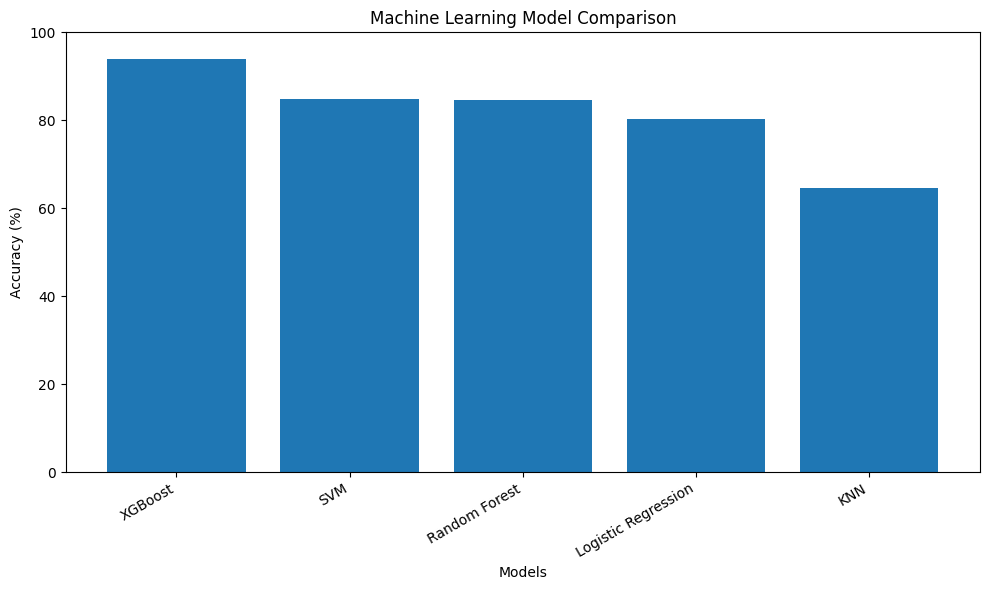

In [26]:
# ============================================================
# 21. MODEL COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["Accuracy (%)"]
)

plt.xlabel("Models")

plt.ylabel("Accuracy (%)")

plt.title(
    "Machine Learning Model Comparison"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.ylim(
    0,
    100
)

plt.tight_layout()

plt.show()

In [27]:
# ============================================================
# 22. BEST MODEL SELECTION
# ============================================================

best_model_name = (
    results_df.iloc[0]["Model"]
)

best_accuracy = (
    results_df.iloc[0]["Accuracy (%)"]
)

print(
    "Best Model:",
    best_model_name
)

print(
    f"Test Accuracy: "
    f"{best_accuracy:.2f}%"
)

Best Model: XGBoost
Test Accuracy: 93.86%


In [29]:
# ============================================================
# 23. CLASSIFICATION REPORT
# ============================================================

# Get the best model
best_model = models[best_model_name]

# Select the correct test features
if best_model_name in [
    "KNN",
    "SVM",
    "Logistic Regression"
]:

    X_best_test = X_test_scaled

else:

    X_best_test = X_test


# Make predictions
best_predictions = best_model.predict(
    X_best_test
)


# Display classification report
print(
    f"Classification Report - {best_model_name}"
)

print()

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Classification Report - XGBoost

               precision    recall  f1-score   support

  fresh apple       0.95      0.98      0.96       320
 fresh banana       1.00      0.99      0.99       309
 fresh orange       0.89      0.94      0.91       313
 rottenapples       0.91      0.86      0.89       296
 rottenbanana       0.98      0.98      0.98       306
rottenoranges       0.91      0.88      0.89       296

     accuracy                           0.94      1840
    macro avg       0.94      0.94      0.94      1840
 weighted avg       0.94      0.94      0.94      1840



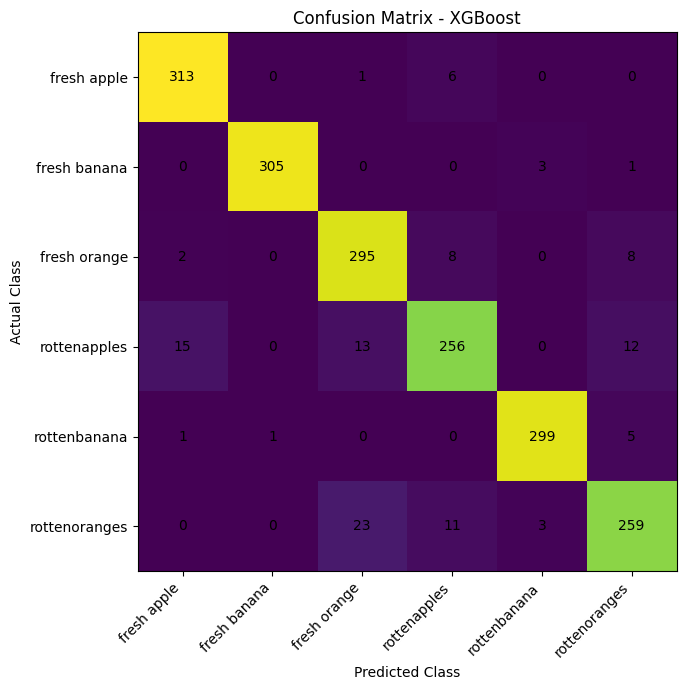

In [30]:
# ============================================================
# 25. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(
    figsize=(9, 7)
)

plt.imshow(
    cm
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    range(
        len(
            label_encoder.classes_
        )
    ),
    label_encoder.classes_,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(
        len(
            label_encoder.classes_
        )
    ),
    label_encoder.classes_
)

for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()

In [31]:
# ============================================================
# 26. SAVE BEST MODEL
# ============================================================

MODEL_DIR = "saved_models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

joblib.dump(
    best_model,
    os.path.join(
        MODEL_DIR,
        "best_model.pkl"
    )
)

joblib.dump(
    scaler,
    os.path.join(
        MODEL_DIR,
        "scaler.pkl"
    )
)

joblib.dump(
    label_encoder,
    os.path.join(
        MODEL_DIR,
        "label_encoder.pkl"
    )
)

joblib.dump(
    best_model_name,
    os.path.join(
        MODEL_DIR,
        "best_model_name.pkl"
    )
)

print(
    "Best model saved successfully."
)

Best model saved successfully.


In [44]:
# ============================================================
# 27. NEW IMAGE PREDICTION
# ============================================================

image_path = "ro1jpeg.jpeg"

new_features = extract_features(
    image_path
)

new_features = new_features.reshape(
    1,
    -1
)

if best_model_name in [
    "KNN",
    "SVM",
    "Logistic Regression"
]:

    new_input = scaler.transform(
        new_features
    )

else:

    new_input = new_features


prediction = best_model.predict(
    new_input
)

predicted_class = (
    label_encoder.inverse_transform(
        prediction
    )[0]
)

print(
    "Predicted Class:",
    predicted_class
)

Predicted Class: rottenoranges


In [45]:
# ============================================================
# 28. PREDICTION CONFIDENCE
# ============================================================

if hasattr(
    best_model,
    "predict_proba"
):

    probabilities = (
        best_model.predict_proba(
            new_input
        )[0]
    )

    confidence = (
        np.max(
            probabilities
        ) * 100
    )

    print(
        f"Prediction: {predicted_class}"
    )

    print(
        f"Confidence: {confidence:.2f}%"
    )

    print()
    print(
        "Class Probabilities:"
    )

    for class_name, probability in zip(
        label_encoder.classes_,
        probabilities
    ):

        print(
            f"{class_name}: "
            f"{probability * 100:.2f}%"
        )

else:

    print(
        f"Prediction: {predicted_class}"
    )

    print(
        "Probability-based confidence "
        "is not available for this model."
    )

Prediction: rottenoranges
Confidence: 99.45%

Class Probabilities:
fresh apple: 0.07%
fresh banana: 0.01%
fresh orange: 0.25%
rottenapples: 0.21%
rottenbanana: 0.02%
rottenoranges: 99.45%
